# **Delhi Weather & AQI Data Visualization**






# **Import Libraries**


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)


# **Load Dataset**

In [41]:
df = pd.read_csv("/content/delhi-weather-aqi-2025.csv")
# Display First 5 Rows
df.head()

,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2
0,01/01/2025,0:00,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,WMO Code 1,197,185.8,188.6,1907,56.7
1,01/01/2025,1:00,Anand Vihar,28.6469,77.316,7.7,100,994.7,3.2,Overcast,WMO Code 3,198,174.6,177.4,1669,44.8
2,01/01/2025,2:00,Anand Vihar,28.6469,77.316,7.5,100,994.3,4.5,Overcast,WMO Code 3,199,164.4,166.7,1493,34.6
3,01/01/2025,3:00,Anand Vihar,28.6469,77.316,7.8,99,994.1,6.0,Overcast,WMO Code 3,200,156.5,158.8,1401,26.7
4,01/01/2025,4:00,Anand Vihar,28.6469,77.316,7.3,100,993.8,6.8,Overcast,WMO Code 3,200,149.5,151.8,1372,20.6


In [42]:
# Check Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date_ist        52560 non-null  object 
 1   time_ist        52560 non-null  object 
 2   location        52560 non-null  object 
 3   lat             52560 non-null  float64
 4   lon             52560 non-null  float64
 5   temp_c          52560 non-null  float64
 6   humidity        52560 non-null  int64  
 7   pressure_mb     52560 non-null  float64
 8   windspeed_kph   52560 non-null  float64
 9   condition_text  52560 non-null  object 
 10  description     52560 non-null  object 
 11  aqi_index       52560 non-null  int64  
 12  pm2_5           52560 non-null  float64
 13  pm10            52560 non-null  float64
 14  co              52560 non-null  int64  
 15  no2             52560 non-null  float64
dtypes: float64(8), int64(3), object(5)
memory usage: 6.4+ MB


In [43]:
#count rows and coloumn
df.shape


(52560, 16)

In [44]:
#Display first  5 rows from bottom
df.tail()

,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2
52555,31/12/2025,19:00,IGI Airport,28.5562,77.1,15.0,88,984.3,7.5,Mainly clear,WMO Code 1,209,148.5,149.0,1517,109.6
52556,31/12/2025,20:00,IGI Airport,28.5562,77.1,14.4,90,984.7,6.6,Partly cloudy,WMO Code 2,209,153.7,154.1,1637,112.5
52557,31/12/2025,21:00,IGI Airport,28.5562,77.1,13.8,92,985.1,5.8,Partly cloudy,WMO Code 2,209,149.5,149.9,1601,100.9
52558,31/12/2025,22:00,IGI Airport,28.5562,77.1,13.4,94,985.1,6.0,Overcast,WMO Code 3,209,146.7,147.1,1476,80.2
52559,31/12/2025,23:00,IGI Airport,28.5562,77.1,13.3,95,985.1,6.5,Partly cloudy,WMO Code 2,208,142.0,142.0,1354,61.5


# **Data Cleaning**
**Check missing values**

In [45]:
df.isnull().sum()

,0
date_ist,0
time_ist,0
location,0
lat,0
lon,0
temp_c,0
humidity,0
pressure_mb,0
windspeed_kph,0
condition_text,0


**Fill or drop missing values**

In [46]:
df.fillna(df.mean(numeric_only=True),inplace=True)

**Remove duplicates**

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.drop_duplicates(inplace=True)

# **Check null values**

In [49]:
df.isnull().sum(axis=1)

,0
0,0
1,0
2,0
3,0
4,0
...,...
52555,0
52556,0
52557,0
52558,0


In [50]:
df.isnull().sum()

,0
date_ist,0
time_ist,0
location,0
lat,0
lon,0
temp_c,0
humidity,0
pressure_mb,0
windspeed_kph,0
condition_text,0


# Fill missing numeric values with median

In [51]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())


In [52]:
df.dropna()

,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2
0,01/01/2025,0:00,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,WMO Code 1,197,185.8,188.6,1907,56.7
1,01/01/2025,1:00,Anand Vihar,28.6469,77.316,7.7,100,994.7,3.2,Overcast,WMO Code 3,198,174.6,177.4,1669,44.8
2,01/01/2025,2:00,Anand Vihar,28.6469,77.316,7.5,100,994.3,4.5,Overcast,WMO Code 3,199,164.4,166.7,1493,34.6
3,01/01/2025,3:00,Anand Vihar,28.6469,77.316,7.8,99,994.1,6.0,Overcast,WMO Code 3,200,156.5,158.8,1401,26.7
4,01/01/2025,4:00,Anand Vihar,28.6469,77.316,7.3,100,993.8,6.8,Overcast,WMO Code 3,200,149.5,151.8,1372,20.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52555,31/12/2025,19:00,IGI Airport,28.5562,77.100,15.0,88,984.3,7.5,Mainly clear,WMO Code 1,209,148.5,149.0,1517,109.6
52556,31/12/2025,20:00,IGI Airport,28.5562,77.100,14.4,90,984.7,6.6,Partly cloudy,WMO Code 2,209,153.7,154.1,1637,112.5
52557,31/12/2025,21:00,IGI Airport,28.5562,77.100,13.8,92,985.1,5.8,Partly cloudy,WMO Code 2,209,149.5,149.9,1601,100.9
52558,31/12/2025,22:00,IGI Airport,28.5562,77.100,13.4,94,985.1,6.0,Overcast,WMO Code 3,209,146.7,147.1,1476,80.2


In [53]:
df.describe()

,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,aqi_index,pm2_5,pm10,co,no2
count,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000
mean,28.608850,77.174567,25.024406,62.285940,983.162635,6.565820,287.364212,89.542432,300.462700,863.844273,35.442757
std,0.058927,0.096519,7.618231,23.454666,6.688582,3.478066,327.979524,55.363812,412.782899,600.845140,28.978905
min,28.527300,77.049400,5.700000,5.000000,966.100000,0.000000,56.000000,6.000000,6.100000,146.000000,1.700000
25%,28.556200,77.100000,19.500000,44.000000,977.500000,4.000000,152.000000,51.100000,80.600000,464.000000,14.900000
50%,28.609300,77.160100,26.500000,65.000000,983.400000,6.000000,170.000000,76.400000,151.800000,664.000000,26.900000
75%,28.646900,77.261800,30.500000,82.000000,988.900000,8.700000,238.000000,110.400000,325.000000,1078.000000,47.100000
max,28.704100,77.316000,43.800000,100.000000,998.800000,27.100000,2742.000000,443.300000,3263.400000,7432.000000,220.100000


# ** Handle Outliers using IQR Method**

In [54]:
for col in numeric_cols:

    # Calculate Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1


In [55]:
 # Define Lower and Upper Limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

    # Replace Outliers
df[col] = np.where(df[col] < lower_limit,
                       lower_limit,
                       df[col])

df[col] = np.where(df[col] > upper_limit,
                       upper_limit,
                       df[col])


# ** Convert Date Column**

In [56]:
# Convert date column into datetime
df["date_ist"] = pd.to_datetime(df["date_ist"], format="%d/%m/%Y")
df.head()


,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2
0,2025-01-01,0:00,Anand Vihar,28.6469,77.316,8.1,100,995.4,2.9,Mainly clear,WMO Code 1,197,185.8,188.6,1907,56.7
1,2025-01-01,1:00,Anand Vihar,28.6469,77.316,7.7,100,994.7,3.2,Overcast,WMO Code 3,198,174.6,177.4,1669,44.8
2,2025-01-01,2:00,Anand Vihar,28.6469,77.316,7.5,100,994.3,4.5,Overcast,WMO Code 3,199,164.4,166.7,1493,34.6
3,2025-01-01,3:00,Anand Vihar,28.6469,77.316,7.8,99,994.1,6.0,Overcast,WMO Code 3,200,156.5,158.8,1401,26.7
4,2025-01-01,4:00,Anand Vihar,28.6469,77.316,7.3,100,993.8,6.8,Overcast,WMO Code 3,200,149.5,151.8,1372,20.6


In [57]:
# Create Year, Month, Day columns
df["Year"] = df["date_ist"].dt.year
df["Month"] = df["date_ist"].dt.month
df["Day"] = df["date_ist"].dt.day


# **Standardize Measurement Units**


In [58]:
# Convert all pollutant columns to numeric
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col],
                            errors='coerce')

In [59]:
# Create Season column
season_map = {
    12:"Winter", 1:"Winter", 2:"Winter",
    3:"Summer", 4:"Summer", 5:"Summer",
    6:"Monsoon", 7:"Monsoon", 8:"Monsoon", 9:"Monsoon",
    10:"Post-Monsoon", 11:"Post-Monsoon"
}

df["Season"] = df["Month"].map(season_map)
df[["Month","Season"]].head()

,Month,Season
0,1,Winter
1,1,Winter
2,1,Winter
3,1,Winter
4,1,Winter


# **Final Check**

In [60]:
print(df.isnull().sum())

# Display Cleaned Data
print(df.head())

date_ist          0
time_ist          0
location          0
lat               0
lon               0
temp_c            0
humidity          0
pressure_mb       0
windspeed_kph     0
condition_text    0
description       0
aqi_index         0
pm2_5             0
pm10              0
co                0
no2               0
Year              0
Month             0
Day               0
Season            0
dtype: int64
    date_ist time_ist     location      lat     lon  temp_c  humidity  \
0 2025-01-01     0:00  Anand Vihar  28.6469  77.316     8.1       100   
1 2025-01-01     1:00  Anand Vihar  28.6469  77.316     7.7       100   
2 2025-01-01     2:00  Anand Vihar  28.6469  77.316     7.5       100   
3 2025-01-01     3:00  Anand Vihar  28.6469  77.316     7.8        99   
4 2025-01-01     4:00  Anand Vihar  28.6469  77.316     7.3       100   

   pressure_mb  windspeed_kph condition_text description  aqi_index  pm2_5  \
0        995.4            2.9   Mainly clear  WMO Code 1        197  1

# **Save Cleaned Dataset**

In [61]:
df.to_csv("cleaned_air_quality_dataset.csv",
          index=False)

print("Data Cleaning Completed Successfully")

Data Cleaning Completed Successfully


# **Data Visualization**

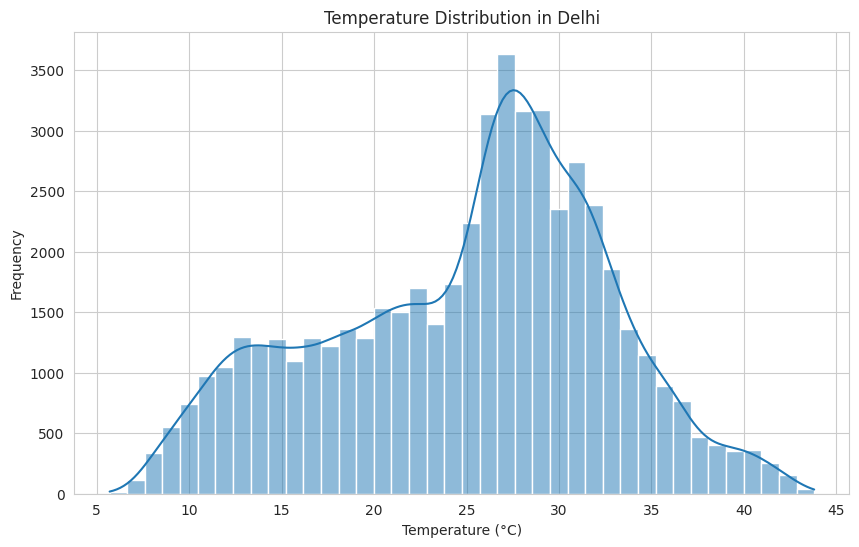

In [62]:
# Temperature Distribution
plt.figure(figsize=(10,6))
sns.histplot(df["temp_c"], bins=40, kde=True)

plt.title("Temperature Distribution in Delhi")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()


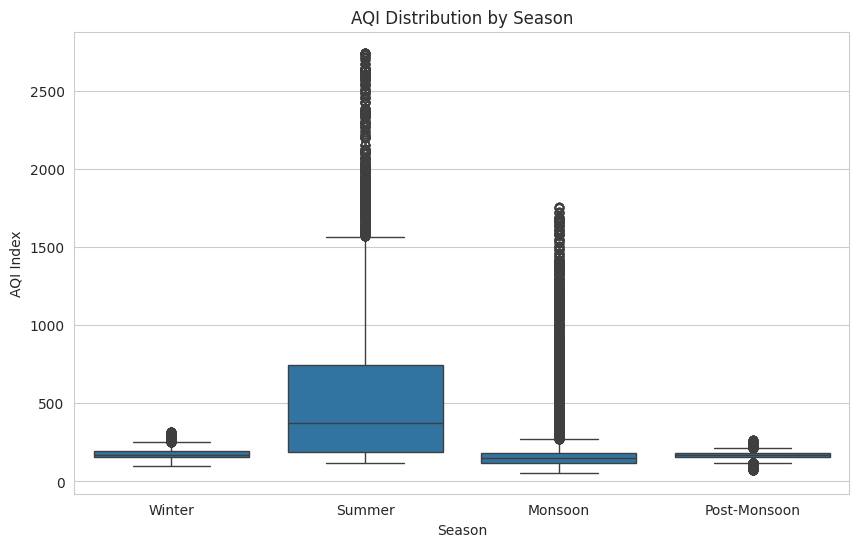

In [63]:
# AQI Distribution by Season
plt.figure(figsize=(10,6))

sns.boxplot(x="Season", y="aqi_index", data=df)

plt.title("AQI Distribution by Season")
plt.xlabel("Season")
plt.ylabel("AQI Index")

plt.show()

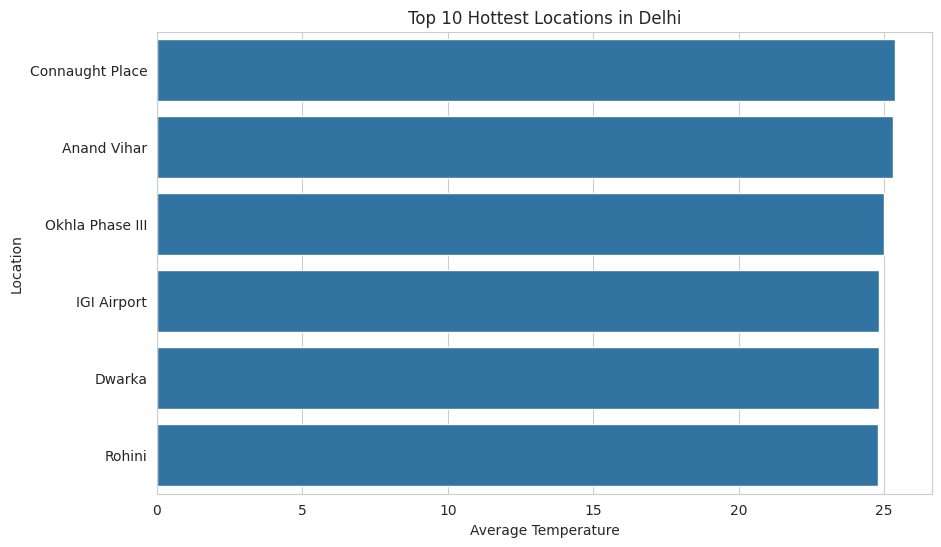

In [64]:
# Average Temperature by Location
top_locations = df.groupby("location")["temp_c"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_locations.values, y=top_locations.index)

plt.title("Top 10 Hottest Locations in Delhi")
plt.xlabel("Average Temperature")
plt.ylabel("Location")

plt.show()

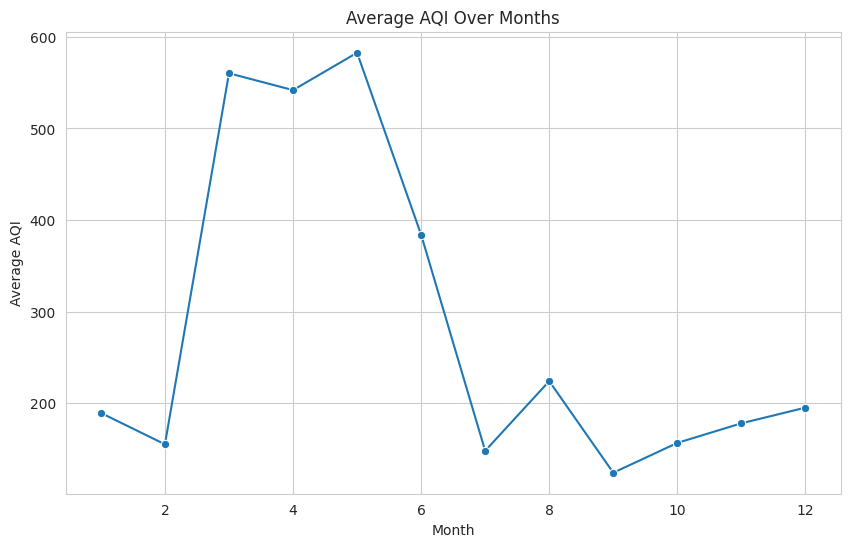

In [65]:
# Average AQI Over Months
monthly_aqi = df.groupby("Month")["aqi_index"].mean()

plt.figure(figsize=(10,6))

sns.lineplot(x=monthly_aqi.index, y=monthly_aqi.values, marker="o")

plt.title("Average AQI Over Months")
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.show()

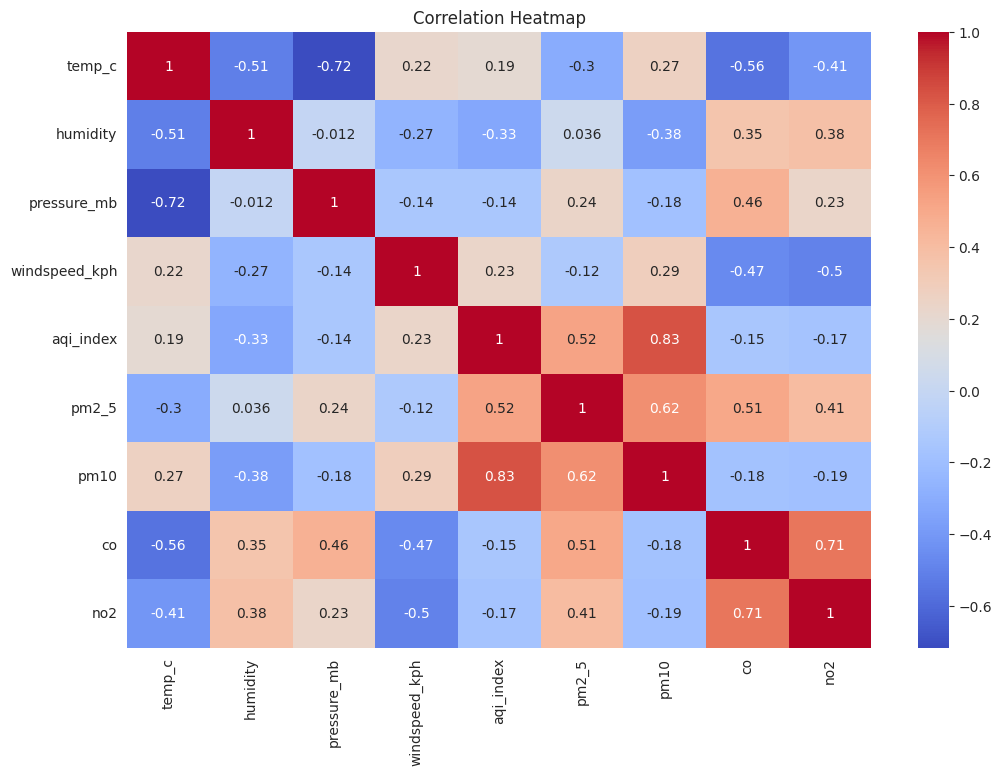

In [66]:
# Correlation Heatmap
cols = ["temp_c","humidity","pressure_mb","windspeed_kph","aqi_index","pm2_5","pm10","co","no2"]

plt.figure(figsize=(12,8))

sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()


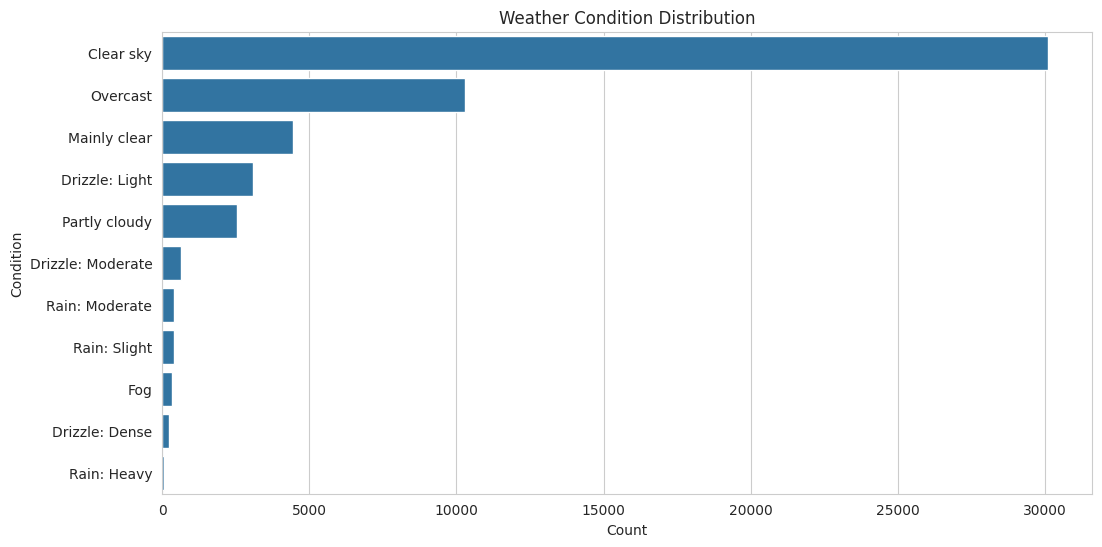

In [67]:
# Weather Condition Distribution
plt.figure(figsize=(12,6))

sns.countplot(y="condition_text", data=df,
              order=df["condition_text"].value_counts().index)

plt.title("Weather Condition Distribution")
plt.xlabel("Count")
plt.ylabel("Condition")

plt.show()


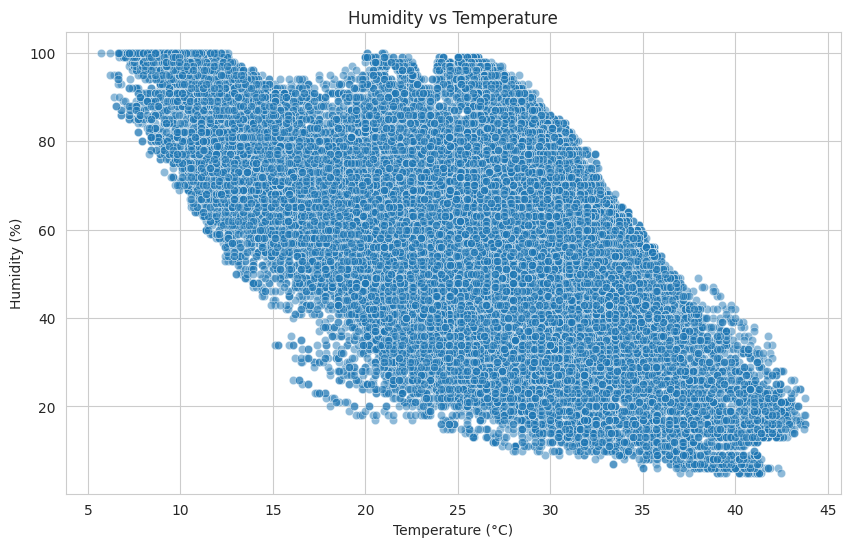

In [68]:
# Humidity vs Temperature
plt.figure(figsize=(10,6))

sns.scatterplot(x="temp_c", y="humidity", data=df, alpha=0.5)

plt.title("Humidity vs Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")

plt.show()


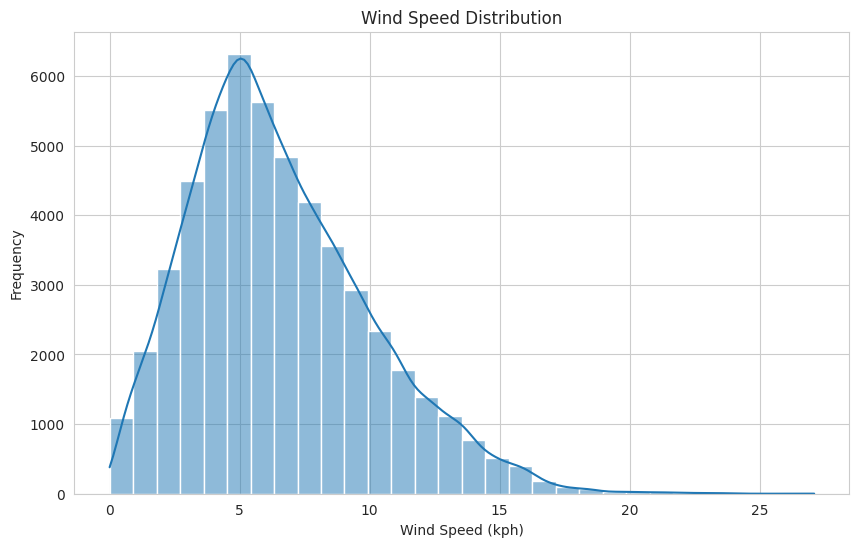

In [69]:
# Wind Speed Distribution
plt.figure(figsize=(10,6))

sns.histplot(df["windspeed_kph"], bins=30, kde=True)

plt.title("Wind Speed Distribution")
plt.xlabel("Wind Speed (kph)")
plt.ylabel("Frequency")

plt.show()

# Conclusion


- Delhi experiences significant seasonal variation in weather and AQI.
- AQI levels tend to worsen during winter months.
- Temperature and humidity show noticeable inverse trends.
- Pollutants such as PM2.5 and PM10 are strongly correlated with AQI.
